# 04 - Modeling: Engineered Features

**Goal:** Re-run the same two models from the baseline notebook (Logistic Regression + Gradient Boosting) 
but now on the full engineered feature matrix from `features.parquet`. 
Compare val AUC-ROC directly against the baseline to measure how much the feature engineering buys us.

**Same pipeline, new features.** Keeping the models identical ensures any performance difference 
is attributable to feature quality, not model choice.

> Train: 500 customers (21 suspicious) | Val: 200 customers (9 suspicious) | Test: 500 (labels withheld)

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

OUT = '../data/'

---
## 1. Load Feature Matrix

Loading `features.parquet` produced by `02_feature_engineering.ipynb`. 
All 64 engineered features are ready — no further transformation needed here except 
converting bool columns to int for sklearn compatibility and confirming no nulls remain.

In [2]:
df = pd.read_parquet(OUT + 'features.parquet')

# Convert bool columns to int (sklearn does not accept bool dtype)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# All columns except metadata
feature_cols = [c for c in df.columns
                if c not in ['customer_id', 'suspicious_activity_confirmed', 'split']
                and df[c].dtype != object]

print(f'Feature columns: {len(feature_cols)}')
print(f'Nulls in features: {df[feature_cols].isnull().sum().sum()}')

Feature columns: 64
Nulls in features: 0


In [3]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()

X_train = train[feature_cols]
y_train = train['suspicious_activity_confirmed'].astype(int)

X_val = val[feature_cols]
y_val = val['suspicious_activity_confirmed'].astype(int)

print(f'Train: {len(X_train)} rows, {y_train.sum()} suspicious ({y_train.mean():.1%})')
print(f'Val:   {len(X_val)} rows, {y_val.sum()} suspicious ({y_val.mean():.1%})')

Train: 500 rows, 21 suspicious (4.2%)
Val:   200 rows, 9 suspicious (4.5%)


---
## 2. Model 1 — Logistic Regression

Same settings as the baseline: `class_weight='balanced'`, scaled features. 
With 64 features and only 21 positives we are in a high-dimensional regime for logistic regression — 
L2 regularisation (default in sklearn) will shrink weak coefficients toward zero, 
which is appropriate here.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_val_proba = lr.predict_proba(X_val_s)[:, 1]
lr_auc   = roc_auc_score(y_val, lr_val_proba)
lr_prauc = average_precision_score(y_val, lr_val_proba)

print(f'Logistic Regression — Val AUC-ROC: {lr_auc:.4f}  |  PR-AUC: {lr_prauc:.4f}')

Logistic Regression — Val AUC-ROC: 0.8453  |  PR-AUC: 0.5074


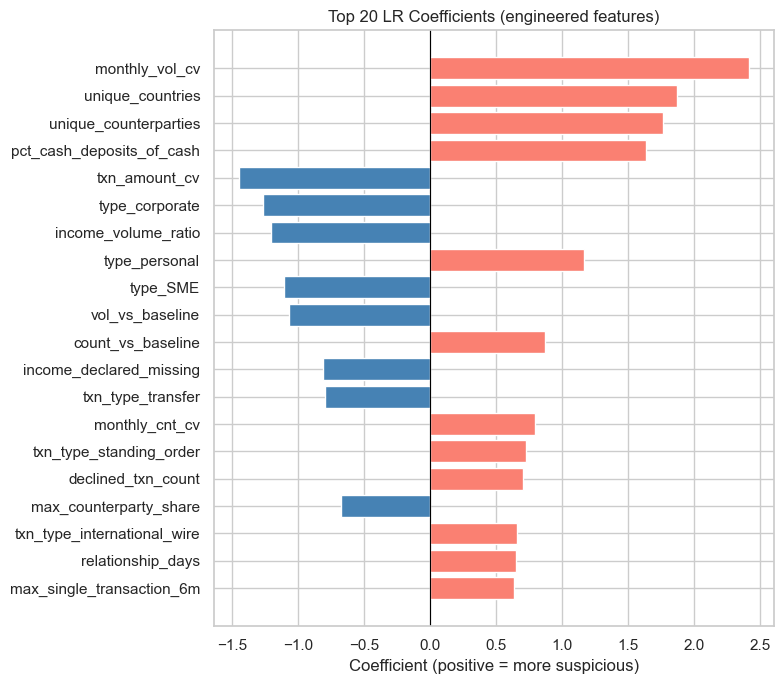

In [5]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 LR Coefficients (engineered features)')
ax.set_xlabel('Coefficient (positive = more suspicious)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. Model 2 — Gradient Boosting

Same hyperparameters as the baseline: shallow trees (`max_depth=3`), `n_estimators=100`, 
`learning_rate=0.05`, `subsample=0.8`. 
With 64 features vs 18 in the baseline, gradient boosting has more combinations to explore — 
if the engineered features carry real signal, this model should show the largest improvement.

In [6]:
sample_weight = np.where(y_train == 1,
    len(y_train) / (2 * y_train.sum()),
    len(y_train) / (2 * (len(y_train) - y_train.sum()))
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weight)

gb_val_proba = gb.predict_proba(X_val)[:, 1]
gb_auc   = roc_auc_score(y_val, gb_val_proba)
gb_prauc = average_precision_score(y_val, gb_val_proba)

print(f'Gradient Boosting   — Val AUC-ROC: {gb_auc:.4f}  |  PR-AUC: {gb_prauc:.4f}')

Gradient Boosting   — Val AUC-ROC: 0.8549  |  PR-AUC: 0.3917


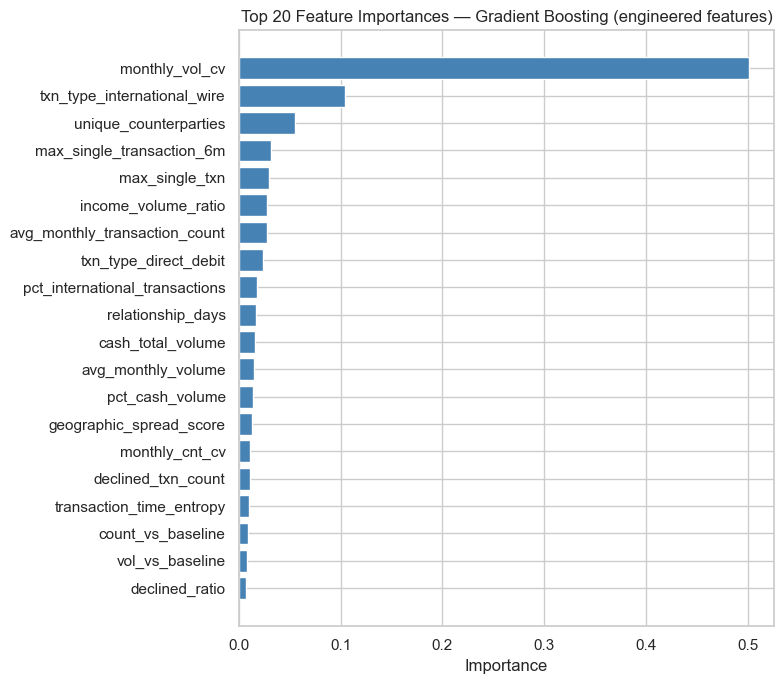

In [7]:
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Gradient Boosting (engineered features)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Compare: Baseline vs Engineered Features

Paste in the baseline scores from `03_modeling.ipynb` to see the delta directly. 
The PR curve matters more than ROC given the 4.5% class imbalance.

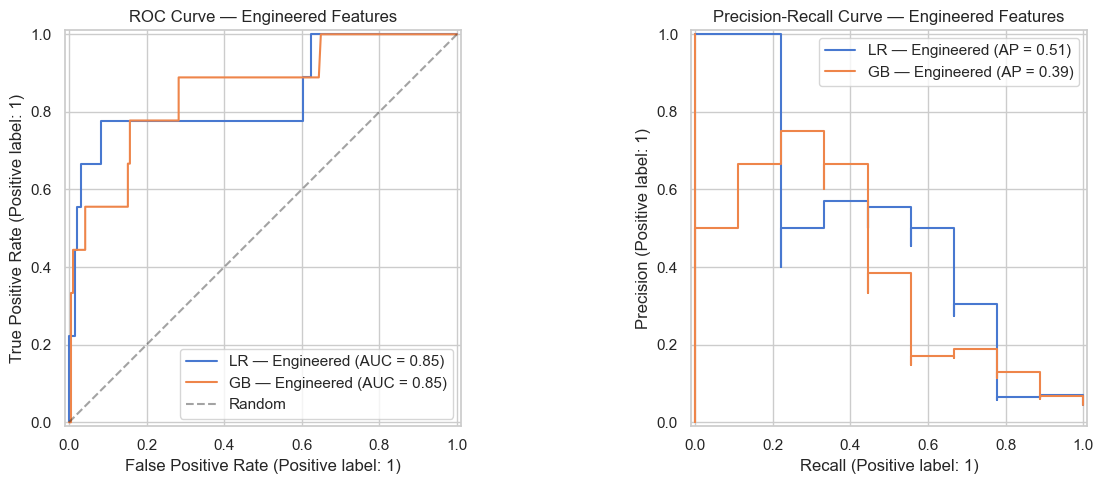

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_val, lr_val_proba, name='LR — Engineered', ax=axes[0])
RocCurveDisplay.from_predictions(y_val, gb_val_proba, name='GB — Engineered', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC Curve — Engineered Features')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_val, lr_val_proba, name='LR — Engineered', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_val, gb_val_proba, name='GB — Engineered', ax=axes[1])
axes[1].set_title('Precision-Recall Curve — Engineered Features')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# --- paste baseline scores from 03_modeling.ipynb here ---
baseline_lr_auc = None   # e.g. 0.7812
baseline_gb_auc = None   # e.g. 0.8034
# ----------------------------------------------------------

print('=' * 55)
print('MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Model":<30} {"AUC-ROC":>8}  {"PR-AUC":>8}')
print('-' * 55)
if baseline_lr_auc:
    print(f'{"LR  — Baseline features":<30} {baseline_lr_auc:>8.4f}')
if baseline_gb_auc:
    print(f'{"GB  — Baseline features":<30} {baseline_gb_auc:>8.4f}')
print(f'{"LR  — Engineered features":<30} {lr_auc:>8.4f}  {lr_prauc:>8.4f}')
print(f'{"GB  — Engineered features":<30} {gb_auc:>8.4f}  {gb_prauc:>8.4f}')
print('=' * 55)
if baseline_gb_auc:
    delta = gb_auc - baseline_gb_auc
    print(f'GB delta (engineered vs baseline): {delta:+.4f}')

MODEL COMPARISON SUMMARY
Model                           AUC-ROC    PR-AUC
-------------------------------------------------------
LR  — Engineered features        0.8453    0.5074
GB  — Engineered features        0.8549    0.3917


---
## 5. Generate Submission File

Once we are satisfied with val performance, retrain the best model on train+val combined 
and generate `predictions.csv` for the 500 organiser test customers.

**Important:** only run this cell when we have decided on the final model. 
Retraining on more data (train+val = 700 customers, 30 suspicious) should improve generalisation.

In [10]:
# Retrain best model on train + val combined
train_val = df[df['split'].isin(['train', 'val'])].copy()
test      = df[df['split'] == 'test'].copy()

X_trainval = train_val[feature_cols]
y_trainval = train_val['suspicious_activity_confirmed'].astype(int)

X_test = test[feature_cols]

sw_trainval = np.where(y_trainval == 1,
    len(y_trainval) / (2 * y_trainval.sum()),
    len(y_trainval) / (2 * (len(y_trainval) - y_trainval.sum()))
)

final_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)

test_proba = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'customer_id': test['customer_id'].values,
    'predicted_probability': test_proba
})

submission.to_csv(OUT + 'predictions.csv', index=False)

print(f'Saved predictions.csv — {len(submission)} rows')
print(submission['predicted_probability'].describe().round(4))

Saved predictions.csv — 500 rows
count    500.0000
mean       0.0718
std        0.1425
min        0.0041
25%        0.0107
50%        0.0168
75%        0.0454
max        0.9320
Name: predicted_probability, dtype: float64
